In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp
pi = np.pi
from scipy.optimize import curve_fit
from scipy.linalg import logm

def get_dissipative_part(rho, L1, L2):
        """
        Both L1 and L2 are Hermitian
        """
        C = rho @ L2
        C_dagger = C.conj().T
        C = C - C_dagger #computes [rho, L2]
        C = L1 @ C
        C_dagger = C.conj().T

        return 0.5 * (C + C_dagger)

def Dyn_rho_2qubits(t, rho_vec, 
                    H, L, gamma_d, sigma_1z, sigma_2z):
    rho = np.reshape(rho_vec, (4, 4))

    #coherent part
    C = H @ rho
    C_dagger = C.conj().T
    drhodt = - 1j * (C - C_dagger)

    #Correlated dissipation 
    drhodt += get_dissipative_part(rho, L, L) + \
        gamma_d[0, 0] * get_dissipative_part(rho, sigma_1z, sigma_1z) + \
        gamma_d[0, 1] * get_dissipative_part(rho, sigma_1z, sigma_2z) + \
        gamma_d[1, 0] * get_dissipative_part(rho, sigma_2z, sigma_1z) + \
        gamma_d[1, 1] * get_dissipative_part(rho, sigma_2z, sigma_2z)
        

    return drhodt.flatten()

sigma_mn = np.array([[0, 0], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

sigma_1mn = np.kron(np.eye(2), sigma_mn)
sigma_1pl = sigma_1mn.T

sigma_2mn = np.kron(sigma_mn, np.eye(2))
sigma_2pl = sigma_2mn.T

sigma_1z = np.kron(np.eye(2), sigma_z)
sigma_2z = np.kron(sigma_z, np.eye(2))


phi1 = np.array([1, 0, 0, 0], dtype=complex)#symmetric up-up state
phi2 = np.array([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0], dtype=complex)#symmetric up-dn state
phi3 = np.array([0, 0, 0, 1], dtype=complex)#symmetric dn-dn state
psi = np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2), 0], dtype=complex)#anti-symmetric up-dn state
 

In [47]:
#Parameters
delta_1z = 0 #detuning on NV_1
delta_2z = 0   #detuning on NV_2
phi = -pi/2
amp_1 = 1.010 * np.exp(1j * phi) # 1.012
amp_2 = 1.062 * np.exp(1j * phi) # 1.115
tau_c = 0.1; Tmax=3000

gamma_d_11 = 20
gamma_d_22 = gamma_d_11
gamma_d_12 = 0. #should be real, represents correlated dephasing
gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

t_span = [0, Tmax] 
t_eval = np.logspace(-2, np.log10(Tmax), 5000); t_eval[-1]=Tmax

H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
    amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
    amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
       )


In [48]:
rho = np.array([[1, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0]],dtype=complex)
rho_vec = rho.flatten()

solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)


sz1_t = np.zeros_like(t_eval, dtype=complex)
sz2_t = np.zeros_like(t_eval, dtype=complex)
sz1sz2_t = np.zeros_like(t_eval, dtype=complex)
ent_entropy_t = np.zeros_like(t_eval, dtype=complex)
threshold = 1e-10

prob_psi = np.zeros_like(t_eval, dtype=complex)
prob_phi1 = np.zeros_like(t_eval, dtype=complex)
prob_phi2 = np.zeros_like(t_eval, dtype=complex)
prob_phi3 = np.zeros_like(t_eval, dtype=complex)

for ind_t in range(len(t_eval)):
    rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
    sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
    sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
    sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]

    eigenvalues, eigenvectors = np.linalg.eigh(rho_t)
    
    significant_eigenvalues = eigenvalues[eigenvalues > threshold]
    if significant_eigenvalues.size > 0:
        ent_entropy_t[ind_t] = -np.sum(significant_eigenvalues * np.log2(significant_eigenvalues))
        # ent_entropy_t[ind_t] = -np.trace(rho_t*logm(rho_t))

    prob_psi[ind_t] = psi.conj().T @ rho_t @ psi
    prob_phi1[ind_t] = phi1.conj().T @ rho_t @ phi1
    prob_phi2[ind_t] = phi2.conj().T @ rho_t @ phi2
    prob_phi3[ind_t] = phi3.conj().T @ rho_t @ phi3


In [44]:
# plt.figure(figsize=(5,3))
# plt.plot(t_eval, prob_psi, label='Psi probability')
# plt.plot(t_eval, prob_phi1, label='Up-Up symmetric')
# plt.plot(t_eval, prob_phi2, label='Up-Dn symmetric')
# plt.plot(t_eval, prob_phi3, label='Dn-Dn symmetric')
# plt.xlabel('Time (t)')
# plt.xlim(0, 3)
# plt.grid(True)
# plt.legend()
# plt.show()

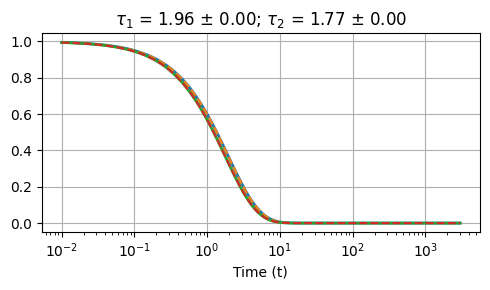

In [49]:
def exp_decay(t, tau):
    return np.exp(- t/tau)
params_QME, covariance_QME = curve_fit(exp_decay, t_eval, sz1_t, p0=[3])
params_QME2, covariance_QME2 = curve_fit(exp_decay, t_eval, sz2_t, p0=[3])

fig,ax = plt.subplots(figsize=(5,3))
ax.plot(t_eval, (sz1_t), label='s1z_QME(t)', linewidth=2)
ax.plot(t_eval, exp_decay(t_eval,params_QME), linestyle='--')
ax.plot(t_eval, (sz2_t), label='s1z_QME(t)', linewidth=2)
ax.plot(t_eval, exp_decay(t_eval,params_QME2), linestyle='--')
ax.set_xlabel('Time (t)')
ax.grid(True)
ax.set_xscale('log')
ax.set_title('$\\tau_1$ = %.2f $\pm$ %.2f; $\\tau_2$ = %.2f $\pm$ %.2f' % (params_QME, np.sqrt(np.diag(covariance_QME)),params_QME2, np.sqrt(np.diag(covariance_QME2))))
plt.tight_layout()

In [50]:
ge = 28025e6*2*pi
B1 = 5.735824889306486 #8.0956e-6
print(1/((ge*B1)**2 * 2*np.sqrt(2*pi) * 100e-9)*1e6)

1.9554077070945633e-12


In [51]:
1.01/ge*1e6*1e6

5.735824889306486

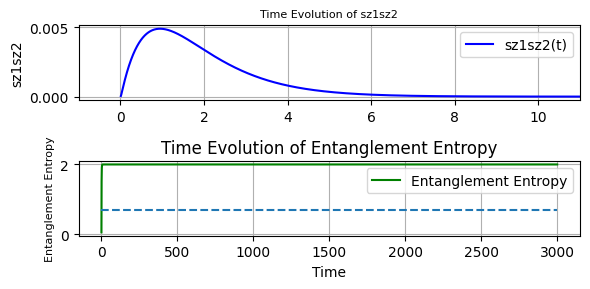

In [52]:
fig, axs = plt.subplots(2, 1, figsize=(6,3))
axs[0].plot(t_eval, sz1sz2_t, label='sz1sz2(t)', color='blue')
axs[0].set_title('Time Evolution of sz1sz2',fontsize=8)
# axs[0].set_xlabel('Time')
axs[0].set_ylabel('sz1sz2')
axs[0].set_xlim((-1,11))
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t_eval, ent_entropy_t, label='Entanglement Entropy', color='green')
axs[1].hlines(y=np.log(2),xmin=min(t_eval), xmax=max(t_eval), linestyle='--')
axs[1].set_title('Time Evolution of Entanglement Entropy')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Entanglement Entropy',fontsize=8)
axs[1].legend()
axs[1].grid(True)

# Adjust the layout so the plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

In [29]:
np.trace(rho_t**2)

(0.24999999999999978+0j)

In [134]:
s1s2=6.75
# xt0 = t_eval; yt0 = sz1sz2_t/4/s1s2
# xt = t_eval; yt = sz1sz2_t/4/s1s2
xt2 = t_eval; yt2 = sz1sz2_t/4/s1s2

# Global fit the data

In [135]:
folder = 'C:/Users/lukin2dmaterials/data/forDeliv/'
file = 'T1SCCRRNoise_batch33_corr_thres25.txt'; path = folder + file; loaded = np.loadtxt(path)
x=loaded[:,0]; ys=loaded[:,1]; yr=loaded[:,2]; errs=loaded[:,3]; errr=loaded[:,4]
idx = np.argsort(x)
x=x[idx]; ys=ys[idx]; yr=yr[idx]; errs=errs[idx]; errr=errr[idx]

file = 'T1SCCRRNoise_batch2425263132_cleaned.txt'; path = folder + file; loaded = np.loadtxt(path)
x2=loaded[:,0]; y2=loaded[:,1]; err2=loaded[:,2]
idx = np.argsort(x2)
x2=x2[idx]; y2=y2[idx]; err2=err2[idx]

file = 'T1SCCRRNoise_batch181920b_corr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
x0 = loaded[:,0]; ys0 = loaded[:,1]; errs0 = loaded[:,2]
file = 'T1SCCRRNoise_batch20a21a_acorr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
xr0 = loaded[:,0]; yr0 = loaded[:,1]; errr0 = loaded[:,2]

y = ((ys/errs**2) - (yr/errr**2))/((1/errs**2) + (1/errr**2))    
err = np.sqrt(1/((1/errs**2) + (1/errr**2)))

y0 = ((ys0/errs0**2) - (yr0/errr0**2))/((1/errs0**2) + (1/errr0**2))    
err0 = np.sqrt(1/((1/errs0**2) + (1/errr0**2)))

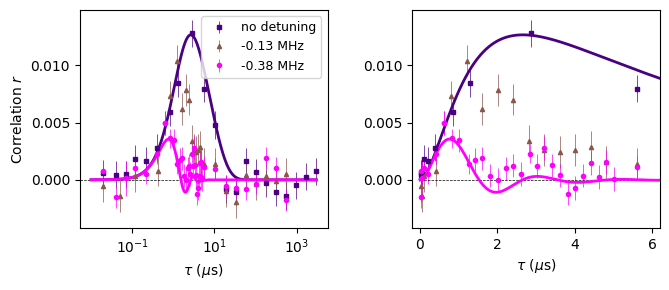

In [136]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

# xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
# xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
# xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
# yt0 = f0(xt0,A,gd0); yt = f(xt,A,gd,phi); yt2 = f2(xt2,A,gd2,phi2)
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    # axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    # axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()